# Trying to undo the off-centre sinogram problems

In [9]:
from skimage.transform import iradon
import numpy as np
import matplotlib.pyplot as plt
import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 1 - PET/Code/Methods.py'>

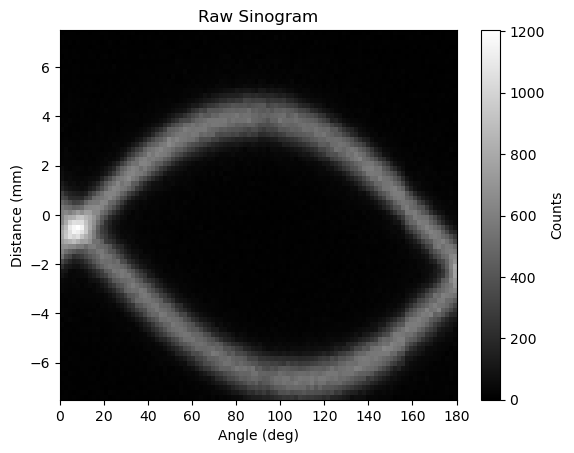

In [11]:
directory = "./data/Measurement run - 2026-01-26"
countArr, uCountArr, distance, angles = m.readSinogram(directory)


angles = angles + 180
m.display_raw_sinogram(countArr, distance, angles, "measurement jan26 sinogram")

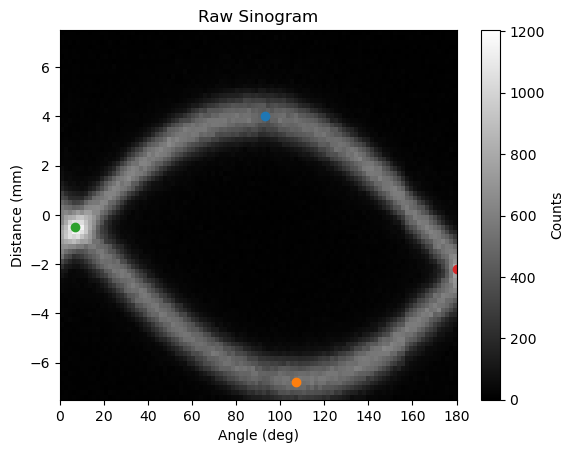

In [21]:
topXY = (93,4)
botXY = (107,-6.8)
LCross = (7,-0.5)
RCross = (180,-2.2)


plt.figure()
plt.scatter(*topXY)
plt.scatter(*botXY)
plt.scatter(*LCross)
plt.scatter(*RCross)
plt.imshow(
    countArr,
    origin="lower",
    aspect="auto",
    extent=[
        angles[0], angles[-1],
        distance[0], distance[-1]],
    cmap="gray"
)
plt.title("Raw Sinogram")
plt.xlabel("Angle (deg)")
plt.ylabel("Distance (mm)")
plt.colorbar(label="Counts")
plt.savefig("figures/Jan 26 sinogram + amplitude detection")
plt.show()

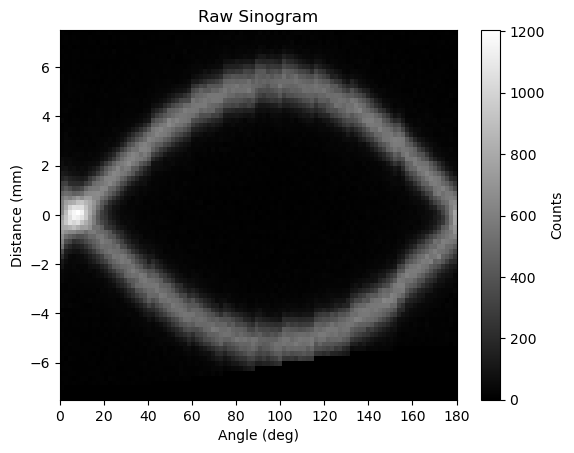

In [24]:
# Correction code is here


# topXY = (90,4)
# botXY = (110,-6.8)
# LCross = (7,-0.7)
# RCross = (180,-2.4)

deltaTheta = botXY[0] - topXY[0]
# print(deltaTheta)
xMid = 0.5*(LCross[1] + RCross[1])
# print(xMid)

ampTop = topXY[1] - xMid
ampBot = abs(botXY[1] - xMid)

# print(ampTop)
# print(ampBot)

constShift = - xMid
cosShift = (LCross[1] - RCross[1])/2

xStep = distance[1] - distance[0]

# xShiftcos = np.zeros_like(angles) - xMid
# ^ linear shift
xShiftcos = - cosShift * np.cos(np.radians(angles)) - xMid
# ^ linear + cosine shift

xShiftcosPixels =  np.round(xShiftcos / xStep).astype(int)
slope = (LCross[1] + RCross[1])/180
# print(xShiftcosPixels)

shiftedCounts = np.zeros_like(countArr)
uShiftedCounts = np.zeros_like(uCountArr)

for j, s in enumerate(xShiftcosPixels):
    if s > 0:
        # Shift DOWN: Zeros at the top, data moves toward higher row indices
        shiftedCounts[s:, j] = countArr[:-s, j]
        uShiftedCounts[s:, j] = uCountArr[:-s, j]
    elif s < 0:
        # Shift UP: Zeros at the bottom, data moves toward lower row indices
        shiftedCounts[:s, j] = countArr[-s:, j]
        uShiftedCounts[:s, j] = uCountArr[-s:, j]

m.display_raw_sinogram(shiftedCounts, distance, angles, "measurement jan26 sinogram - shifted")

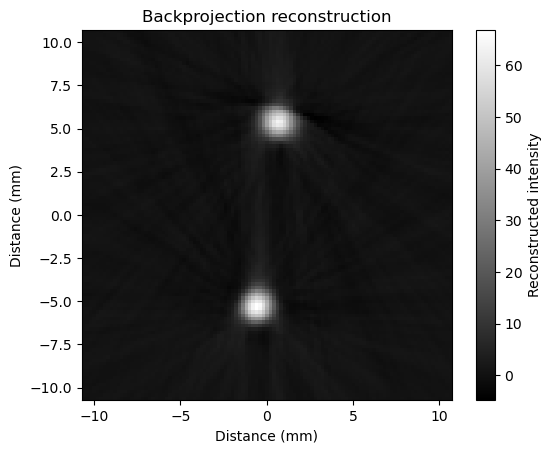

In [25]:
recon = iradon(shiftedCounts, theta=angles, output_size=int(len(distance) * np.sqrt(2)), filter_name="cosine", circle=False)

dimx, dimy = recon.shape # dims are the same since it has to be square
total_physical_width = dimx * (distance[1]- distance[0])
half_width = total_physical_width / 2
recon_distance = np.linspace(-half_width, half_width, dimx)

m.display_reconstructed_image(recon, recon_distance, "Jan 26 reconstruction - corrected")